# OpenStreetMap (OSM)

## Introduction

This tutorial focuses on using graphfaker to generate OpenStreetMap (OSM) road networks. You will learn how to:
- Fetch an OSM network for a specific area.
- Visualize the network.
- Perform basic graph operations like shortest path and degree analysis.
- Export the graph for further use.

You can explore the full notebook locally or open it in Google Colab:

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/drive/1nOSc6NzE3U14KZ5cY08nO28B7CdXoJ4z?usp=sharing)


### Step 1: Import and Initialize

In [ ]:
# If you haven't installed graphfaker yet:
# !pip install graphfaker

In [3]:
from graphfaker import GraphFaker
import networkx as nx
import matplotlib.pyplot as plt

# Initialize the GraphFaker
gf = GraphFaker()

### Step 2: Fetch an OSM Network

You can fetch a road network for a city, specific address, or bounding box.

In [4]:
# Example: road network for Castellón de la Plana, Spain
osm_graph = gf.generate_graph(
    source="osm",
    place="Castellón de la Plana, Spain",
    network_type="drive"  # options: "drive", "walk", "bike", etc.
)

print(f"OSM graph: {osm_graph.number_of_nodes()} nodes, {osm_graph.number_of_edges()} edges")

graphfaker:2025-08-24 12:34:38,215 - graphfaker - INFO - Generating OSM graph with source=osm, place=Castellón de la Plana, Spain, address=None, bbox=None, network_type=drive, simplify=True, retain_all=False, dist=1000
INFO:graphfaker:Generating OSM graph with source=osm, place=Castellón de la Plana, Spain, address=None, bbox=None, network_type=drive, simplify=True, retain_all=False, dist=1000
graphfaker:2025-08-24 12:34:38,221 - graphfaker - INFO - Fetching OSM network with parameters: place=Castellón de la Plana, Spain, address=None, bbox=None, network_type=drive, simplify=True, retain_all=False, dist=1000
INFO:graphfaker:Fetching OSM network with parameters: place=Castellón de la Plana, Spain, address=None, bbox=None, network_type=drive, simplify=True, retain_all=False, dist=1000


OSM graph: 5071 nodes, 10086 edges


### Step 3: Visualize the Network

For large networks, plotting the full graph may be slow. We can plot a subset or use simplified layouts.

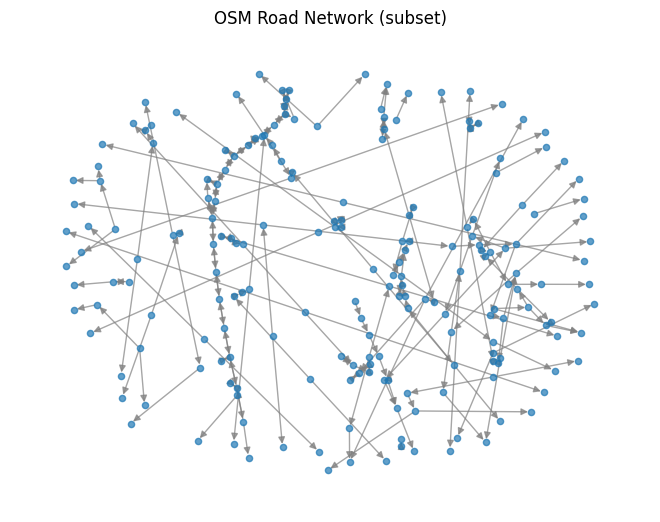

In [5]:
# Plot a subset of 200 nodes
nodes_to_plot = list(osm_graph.nodes())[:200]
subgraph = osm_graph.subgraph(nodes_to_plot)

pos = nx.spring_layout(subgraph, seed=42)  # Layout for visualization
nx.draw(subgraph, pos, node_size=20, alpha=0.7, edge_color="gray")
plt.title("OSM Road Network (subset)")
plt.show()

### Step 4: Analyze the Network

#### Example 1: Node Degree Distribution

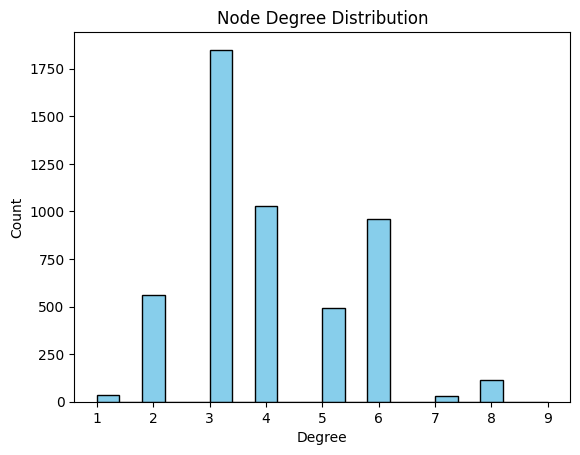

In [6]:
degrees = [d for _, d in osm_graph.degree()]
plt.hist(degrees, bins=20, color="skyblue", edgecolor="black")
plt.title("Node Degree Distribution")
plt.xlabel("Degree")
plt.ylabel("Count")
plt.show()

#### Example 2: Shortest Path

In [10]:
nodes = list(osm_graph.nodes())
source, target = nodes[4], nodes[100]

if nx.has_path(osm_graph, source, target):
    path = nx.shortest_path(osm_graph, source=source, target=target, weight="length")
    print(f"Shortest path from {source} to {target}: {path}")
else:
    print(f"No path between {source} and {target}")


Shortest path from 275040659 to 237778731: [275040659, 4645845447, 275039976, 275039996, 275039004, 275039006, 275039569, 275039571, 275039573, 275039581, 237781112, 237780985, 237780952, 9721054783, 9721054780, 237780917, 6019817960, 237780906, 6019817962, 237780890, 390982212, 237780887, 237780883, 390982225, 237780876, 237780870, 237780867, 275046222, 260493224, 260493230, 260493232, 260493234, 260493236, 261658959, 261652009, 261652627, 261652013, 261651583, 261651585, 261651587, 261651589, 261656390, 259717434, 260488314, 390927291, 2175348075, 390927293, 390927203, 11812484240, 262247521, 237778698, 237778705, 237778710, 237778718, 237778727, 237778731]


### Step 5: Export the Graph

You can save the graph for use in tools like Gephi, Cytoscape, or for later analysis.

In [11]:
gf.export_graph(osm_graph, source="osm", path="osm_graph.graphml")

✅ Graph exported to: /content/osm_graph.graphml



### Summary

- Fetched an OSM road network with `graphfaker`.

- Visualized the network and subsets for clarity.

- Explored basic metrics like degree and shortest paths.

- Exported the network for external use.